# E-Commerce Order Value Analysis & Prediction

## Project Overview

This project analyzes an e-commerce order dataset and develops machine learning regression models to predict `TotalPrice`.

The analysis covers:
- Data inspection
- Exploratory data analysis
- Missing-value treatment
- Outlier detection and treatment
- Feature engineering
- Data transformation and encoding
- Feature selection
- Train-test splitting and scaling
- Regression model development
- Model evaluation
- Feature importance analysis
- Findings and recommendations

## Dataset

- Records: 1,200
- Original features: 14
- Target variable: `TotalPrice`
- Date range: January 2023 – June 2025

## 1. Dataset Loading and Initial Inspection

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

> Note: The original dataset is not included in this repository because it was provided separately for the project.

In [3]:
# Load dataset
df = pd.read_excel("/content/Dataset for Data Analytics.xlsx")

# Dataset dimensions
print("Dataset Shape:", df.shape)

# Column names
print("\nColumn Names:")
print(df.columns.tolist())

# Data types
print("\nData Types:")
print(df.dtypes)

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Duplicate records
print("\nDuplicate Rows:", df.duplicated().sum())

# Basic numerical statistics
print("\nStatistical Summary:")
print(df.describe())

Dataset Shape: (1200, 14)

Column Names:
['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice']

Data Types:
OrderID                    object
Date               datetime64[ns]
CustomerID                 object
Product                    object
Quantity                    int64
UnitPrice                 float64
ShippingAddress            object
PaymentMethod              object
OrderStatus                object
TrackingNumber             object
ItemsInCart                 int64
CouponCode                 object
ReferralSource             object
TotalPrice                float64
dtype: object

Missing Values:
OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCa

## 2. Exploratory Data Analysis

The exploratory analysis examines the distribution of numerical variables and the distribution of key categorical variables.


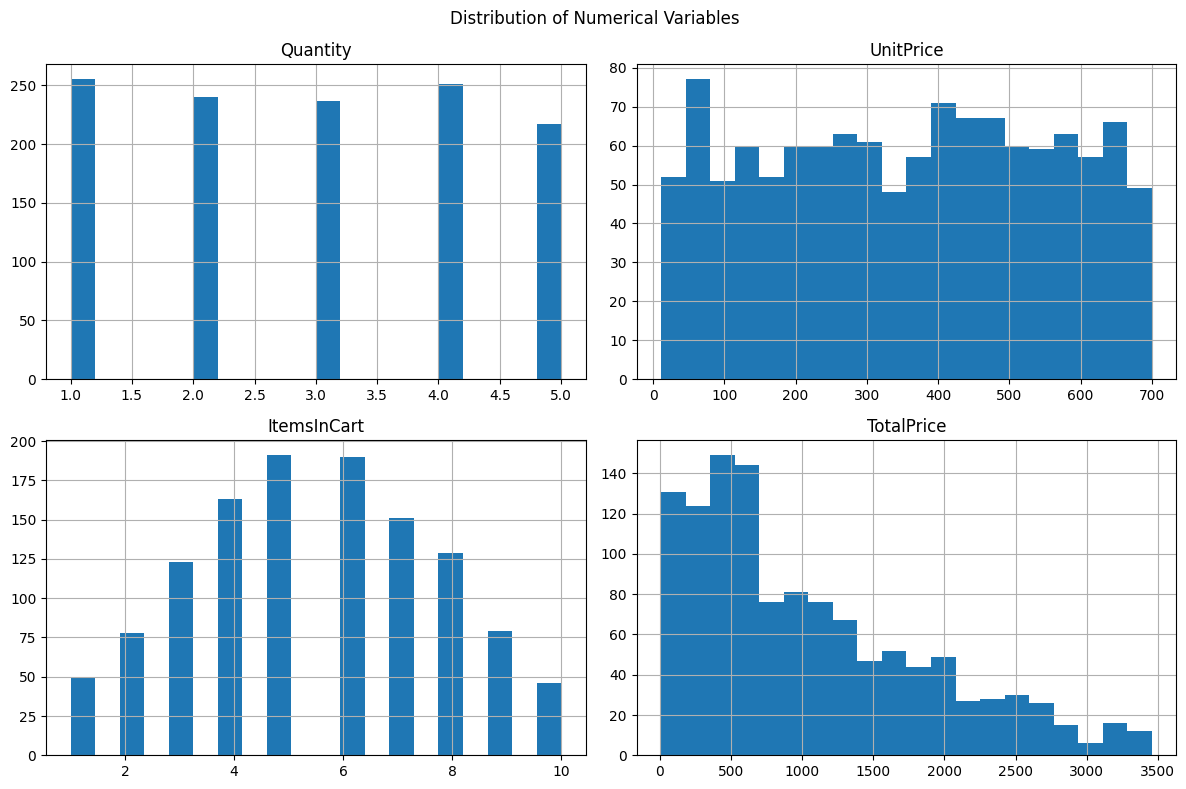

In [4]:
# Numerical columns
numeric_cols = ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']

# Histograms
df[numeric_cols].hist(figsize=(12, 8), bins=20)

plt.suptitle("Distribution of Numerical Variables")
plt.tight_layout()
plt.show()

In [5]:
# Categorical variable distributions

categorical_cols = ['Product', 'PaymentMethod', 'OrderStatus', 'ReferralSource']

for col in categorical_cols:
    print(f"\n{'='*50}")
    print(f"{col} Distribution")
    print(f"{'='*50}")
    print(df[col].value_counts())


Product Distribution
Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64

PaymentMethod Distribution
PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64

OrderStatus Distribution
OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

ReferralSource Distribution
ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64


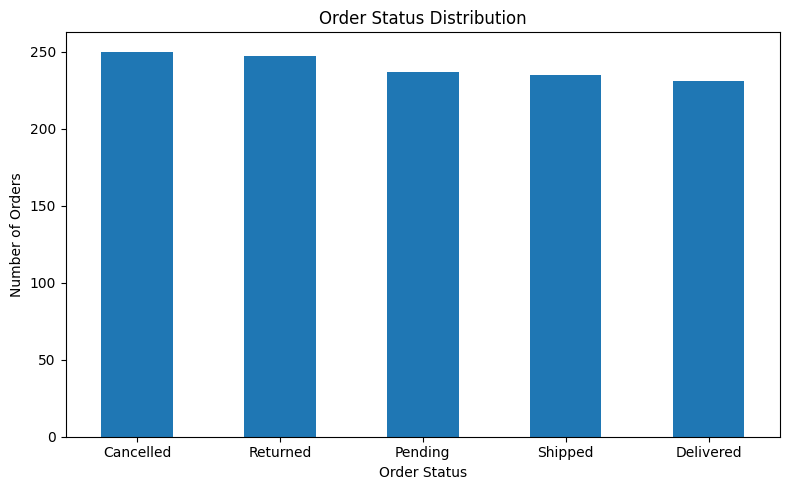

In [6]:
# Order Status distribution
status_counts = df['OrderStatus'].value_counts()

plt.figure(figsize=(8, 5))
status_counts.plot(kind='bar')

plt.title('Order Status Distribution')
plt.xlabel('Order Status')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [7]:
# Correlation matrix for numerical variables

numeric_cols = ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']

correlation_matrix = df[numeric_cols].corr()

print("Correlation Matrix:")
print(correlation_matrix.round(2))


Correlation Matrix:
             Quantity  UnitPrice  ItemsInCart  TotalPrice
Quantity         1.00       0.01         0.65        0.62
UnitPrice        0.01       1.00         0.00        0.72
ItemsInCart      0.65       0.00         1.00        0.39
TotalPrice       0.62       0.72         0.39        1.00


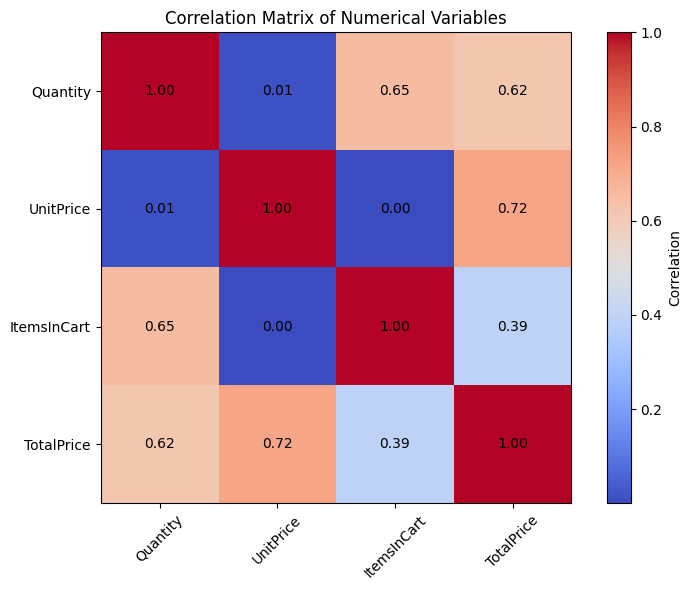

In [8]:
plt.figure(figsize=(8, 6))

plt.imshow(correlation_matrix, cmap='coolwarm', interpolation='nearest')
plt.colorbar(label='Correlation')

plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45)
plt.yticks(range(len(numeric_cols)), numeric_cols)

plt.title('Correlation Matrix of Numerical Variables')

# Add correlation values
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        plt.text(j, i, f'{correlation_matrix.iloc[i, j]:.2f}',
                 ha='center', va='center')

plt.tight_layout()
plt.show()

## 3. Missing Value Treatment

The CouponCode column contained 309 missing values. These values were interpreted as orders where no coupon was applied and were replaced with "No Coupon".

In [9]:
# Inspect CouponCode values

print("Coupon Code Distribution:")
print(df['CouponCode'].value_counts(dropna=False))

print("\nNumber of unique coupon codes:")
print(df['CouponCode'].nunique(dropna=True))

Coupon Code Distribution:
CouponCode
FREESHIP    313
NaN         309
WINTER15    292
SAVE10      286
Name: count, dtype: int64

Number of unique coupon codes:
3


In [10]:
# Create a cleaned copy of the original dataset
df_clean = df.copy()

# Replace missing coupon codes with a meaningful category
df_clean['CouponCode'] = df_clean['CouponCode'].fillna('No Coupon')

# Check missing values after treatment
print("Missing values in CouponCode after treatment:")
print(df_clean['CouponCode'].isnull().sum())

# Check the updated distribution
print("\nUpdated CouponCode Distribution:")
print(df_clean['CouponCode'].value_counts())

Missing values in CouponCode after treatment:
0

Updated CouponCode Distribution:
CouponCode
FREESHIP     313
No Coupon    309
WINTER15     292
SAVE10       286
Name: count, dtype: int64


## 4. Outlier Detection and Treatment
The IQR method was used to identify potential outliers in numerical variables. Eight outliers were identified in TotalPrice. These values were capped at the upper IQR boundary of 3330.4075.

In [11]:
# Outlier detection using IQR

numeric_cols = ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']

outlier_summary = []

for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_clean[
        (df_clean[col] < lower_bound) |
        (df_clean[col] > upper_bound)
    ]

    outlier_summary.append({
        'Column': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outlier Count': len(outliers)
    })

outlier_summary_df = pd.DataFrame(outlier_summary)

print(outlier_summary_df)

        Column        Q1        Q3        IQR  Lower Bound  Upper Bound  \
0     Quantity    2.0000     4.000     2.0000     -1.00000      7.00000   
1    UnitPrice  186.0625   521.570   335.5075   -317.19875   1024.83125   
2  ItemsInCart    4.0000     7.000     3.0000     -0.50000     11.50000   
3   TotalPrice  410.5200  1578.475  1167.9550  -1341.41250   3330.40750   

   Outlier Count  
0              0  
1              0  
2              0  
3              8  


In [12]:
# Identify TotalPrice outliers

Q1 = df_clean['TotalPrice'].quantile(0.25)
Q3 = df_clean['TotalPrice'].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

totalprice_outliers = df_clean[
    df_clean['TotalPrice'] > upper_bound
]

print("Upper IQR Bound:", upper_bound)
print("\nTotalPrice Outliers:")
print(
    totalprice_outliers[
        ['OrderID', 'Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']
    ].sort_values('TotalPrice', ascending=False)
)

Upper IQR Bound: 3330.4075

TotalPrice Outliers:
        OrderID  Quantity  UnitPrice  ItemsInCart  TotalPrice
789   ORD200789         5     691.28           10     3456.40
1122  ORD201122         5     678.19            8     3390.95
632   ORD200632         5     678.16            7     3390.80
469   ORD200469         5     676.98            5     3384.90
328   ORD200328         5     674.04            7     3370.20
107   ORD200107         5     670.75            8     3353.75
326   ORD200326         5     670.48            5     3352.40
1065  ORD201065         5     666.80            7     3334.00


In [13]:
Q1 = df_clean['TotalPrice'].quantile(0.25)
Q3 = df_clean['TotalPrice'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean['TotalPrice_Original'] = df_clean['TotalPrice']
df_clean['TotalPrice'] = df_clean['TotalPrice'].clip(lower=lower_bound, upper=upper_bound)

print("Upper IQR Bound:", upper_bound)
print("Original Maximum:", df_clean['TotalPrice_Original'].max())
print("Maximum After Capping:", df_clean['TotalPrice'].max())
print("Number of Values Capped:", (df_clean['TotalPrice_Original'] > upper_bound).sum())

Upper IQR Bound: 3330.4075
Original Maximum: 3456.4
Maximum After Capping: 3330.4075
Number of Values Capped: 8


In [14]:
print("Maximum TotalPrice after treatment:", df_clean['TotalPrice'].max())
print("Values above IQR upper bound:", (df_clean['TotalPrice'] > upper_bound).sum())
print("Total number of records:", len(df_clean))

Maximum TotalPrice after treatment: 3330.4075
Values above IQR upper bound: 0
Total number of records: 1200


## 5. Feature Engineering
Three new features were created:

1. CalculatedTotal
2. PricePerCartItem
3. OrderValueCategor

In [15]:
df_clean['CalculatedTotal'] = df_clean['Quantity'] * df_clean['UnitPrice']

df_clean['PricePerCartItem'] = df_clean['TotalPrice'] / df_clean['ItemsInCart']

df_clean['OrderValueCategory'] = pd.cut(
df_clean['TotalPrice'],
bins=[-float('inf'), 500, 1500, float('inf')],
labels=['Low Value', 'Medium Value', 'High Value']
)

print("New Features Created:")
print(df_clean[['CalculatedTotal', 'PricePerCartItem', 'OrderValueCategory']].head())
print("\nNew Dataset Shape:", df_clean.shape)

New Features Created:
   CalculatedTotal  PricePerCartItem OrderValueCategory
0          2853.10        407.585714         High Value
1           302.70        100.900000          Low Value
2          2753.40        344.175000         High Value
3           273.19         54.638000          Low Value
4          2504.04        313.005000         High Value

New Dataset Shape: (1200, 18)


## 6. Data Transformation and Encoding

In [16]:
print(df_clean.dtypes)

OrderID                        object
Date                   datetime64[ns]
CustomerID                     object
Product                        object
Quantity                        int64
UnitPrice                     float64
ShippingAddress                object
PaymentMethod                  object
OrderStatus                    object
TrackingNumber                 object
ItemsInCart                     int64
CouponCode                     object
ReferralSource                 object
TotalPrice                    float64
TotalPrice_Original           float64
CalculatedTotal               float64
PricePerCartItem              float64
OrderValueCategory           category
dtype: object


In [17]:
df_model = df_clean.drop(columns=['OrderID', 'CustomerID', 'ShippingAddress', 'TrackingNumber'])
print("Original cleaned dataset shape:", df_clean.shape)
print("Model-ready dataset shape:", df_model.shape)

Original cleaned dataset shape: (1200, 18)
Model-ready dataset shape: (1200, 14)


In [18]:
df_model['OrderYear'] = df_model['Date'].dt.year
df_model['OrderMonth'] = df_model['Date'].dt.month
df_model['OrderDayOfWeek'] = df_model['Date'].dt.dayofweek
df_model = df_model.drop(columns=['Date'])
print(df_model[['OrderYear', 'OrderMonth', 'OrderDayOfWeek']].head())
print("\nDataset Shape:", df_model.shape)

   OrderYear  OrderMonth  OrderDayOfWeek
0       2023           1               2
1       2024           8               4
2       2024           2               1
3       2023          10               6
4       2025           5               3

Dataset Shape: (1200, 16)


In [19]:
categorical_cols = ['Product', 'PaymentMethod', 'OrderStatus', 'CouponCode', 'ReferralSource', 'OrderValueCategory']
df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True, dtype=int)
print("Dataset Shape After Encoding:", df_model.shape)
print("\nData Types:")
print(df_model.dtypes)

Dataset Shape After Encoding: (1200, 33)

Data Types:
Quantity                             int64
UnitPrice                          float64
ItemsInCart                          int64
TotalPrice                         float64
TotalPrice_Original                float64
CalculatedTotal                    float64
PricePerCartItem                   float64
OrderYear                            int32
OrderMonth                           int32
OrderDayOfWeek                       int32
Product_Desk                         int64
Product_Laptop                       int64
Product_Monitor                      int64
Product_Phone                        int64
Product_Printer                      int64
Product_Tablet                       int64
PaymentMethod_Credit Card            int64
PaymentMethod_Debit Card             int64
PaymentMethod_Gift Card              int64
PaymentMethod_Online                 int64
OrderStatus_Delivered                int64
OrderStatus_Pending                  int64


## 7. Target Variable and Feature Selection


In [20]:
y = df_model['TotalPrice']
X = df_model.drop(columns=['TotalPrice', 'TotalPrice_Original', 'PricePerCartItem',
                           'OrderValueCategory_Medium Value', 'OrderValueCategory_High Value'])

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("\nTarget variable:", y.name)
print("\nFeature columns:")
print(X.columns.tolist())

Features (X) shape: (1200, 28)
Target (y) shape: (1200,)

Target variable: TotalPrice

Feature columns:
['Quantity', 'UnitPrice', 'ItemsInCart', 'CalculatedTotal', 'OrderYear', 'OrderMonth', 'OrderDayOfWeek', 'Product_Desk', 'Product_Laptop', 'Product_Monitor', 'Product_Phone', 'Product_Printer', 'Product_Tablet', 'PaymentMethod_Credit Card', 'PaymentMethod_Debit Card', 'PaymentMethod_Gift Card', 'PaymentMethod_Online', 'OrderStatus_Delivered', 'OrderStatus_Pending', 'OrderStatus_Returned', 'OrderStatus_Shipped', 'CouponCode_No Coupon', 'CouponCode_SAVE10', 'CouponCode_WINTER15', 'ReferralSource_Facebook', 'ReferralSource_Google', 'ReferralSource_Instagram', 'ReferralSource_Referral']


In [21]:
print("CalculatedTotal vs TotalPrice:")
print("Correlation:", df_model['CalculatedTotal'].corr(df_model['TotalPrice']))
print("Maximum absolute difference:", abs(df_model['CalculatedTotal']
                                          - df_model['TotalPrice']).max())
print("\nTarget Statistics:")
print(y.describe())

CalculatedTotal vs TotalPrice:
Correlation: 0.9999828313658631
Maximum absolute difference: 125.99249999999984

Target Statistics:
count    1200.000000
mean     1053.643183
std       818.937858
min        11.390000
25%       410.520000
50%       823.615000
75%      1578.475000
max      3330.407500
Name: TotalPrice, dtype: float64


In [22]:
X = X.drop(columns=['CalculatedTotal'])

print("Final Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("\nCalculatedTotal still in X:", 'CalculatedTotal' in X.columns)

Final Features (X) shape: (1200, 27)
Target (y) shape: (1200,)

CalculatedTotal still in X: False


### Feature Selection

CalculatedTotal was excluded from the final feature set because it was almost perfectly correlated with TotalPrice (correlation = 0.99998). Retaining this variable could introduce target leakage or an overly direct representation of the target relationship.

The final feature matrix contained 27 predictors.

## 8. Train-Test Split and Feature Scaling

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.20, random_state=42
)

print("Training Features (X_train):", X_train.shape)
print("Testing Features (X_test):", X_test.shape)
print("Training Target (y_train):", y_train.shape)
print("Testing Target (y_test):", y_test.shape)

Training Features (X_train): (960, 27)
Testing Features (X_test): (240, 27)
Training Target (y_train): (960,)
Testing Target (y_test): (240,)


In [24]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled Training Features Shape:", X_train_scaled.shape)
print("Scaled Testing Features Shape:", X_test_scaled.shape)

Scaled Training Features Shape: (960, 27)
Scaled Testing Features Shape: (240, 27)


## 9. Model Building

Three regression models were trained:

1. Linear Regression
2. Decision Tree Regressor
3. Random Forest Regressor

In [25]:
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)
y_pred_linear = linear_model.predict(X_test_scaled)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [26]:
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train_scaled, y_train)
y_pred_tree = tree_model.predict(X_test_scaled)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [27]:
forest_model = RandomForestRegressor(n_estimators=100, random_state=42)
forest_model.fit(X_train_scaled, y_train)
y_pred_forest = forest_model.predict(X_test_scaled)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


## 10. Model Evaluation

In [28]:
mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
r2_linear = r2_score(y_test, y_pred_linear)
mae_tree = mean_absolute_error(y_test, y_pred_tree)
mse_tree = mean_squared_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mse_tree)
r2_tree = r2_score(y_test, y_pred_tree)
mae_forest = mean_absolute_error(y_test, y_pred_forest)
mse_forest = mean_squared_error(y_test, y_pred_forest)
rmse_forest = np.sqrt(mse_forest)
r2_forest = r2_score(y_test, y_pred_forest)

print("MODEL EVALUATION RESULTS")
print("\nLinear Regression")
print("MAE:", mae_linear)
print("MSE:", mse_linear)
print("RMSE:", rmse_linear)
print("R²:", r2_linear)
print("\nDecision Tree")
print("MAE:", mae_tree)
print("MSE:", mse_tree)
print("RMSE:", rmse_tree)
print("R²:", r2_tree)
print("\nRandom Forest")
print("MAE:", mae_forest)
print("MSE:", mse_forest)
print("RMSE:", rmse_forest)
print("R²:", r2_forest)

MODEL EVALUATION RESULTS

Linear Regression
MAE: 219.3926209126798
MSE: 84970.12137907669
RMSE: 291.4963488263218
R²: 0.8877772666843239

Decision Tree
MAE: 14.92855208333332
MSE: 1054.886986744792
RMSE: 32.47902379605631
R²: 0.9986067773110091

Random Forest
MAE: 8.649012187500107
MSE: 211.86349652923914
RMSE: 14.555531475327143
R²: 0.9997201851629203


### Interpretation

Random Forest achieved the strongest overall performance, with the lowest MAE, MSE, and RMSE and the highest R² score.

## 11. Feature Importance and Model Interpretation

In [29]:
feature_importance = pd.DataFrame({
'Feature': X.columns,
'Importance': forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
by='Importance', ascending=False
)

print(feature_importance.to_string(index=False))

                  Feature  Importance
                UnitPrice    0.532861
                 Quantity    0.466651
              ItemsInCart    0.000072
               OrderMonth    0.000066
           OrderDayOfWeek    0.000057
  ReferralSource_Facebook    0.000023
                OrderYear    0.000021
          Product_Monitor    0.000021
           Product_Laptop    0.000018
     CouponCode_No Coupon    0.000017
    OrderStatus_Delivered    0.000016
    ReferralSource_Google    0.000016
PaymentMethod_Credit Card    0.000015
        CouponCode_SAVE10    0.000014
 PaymentMethod_Debit Card    0.000014
     OrderStatus_Returned    0.000012
      OrderStatus_Shipped    0.000012
  PaymentMethod_Gift Card    0.000012
      OrderStatus_Pending    0.000011
 ReferralSource_Instagram    0.000011
      CouponCode_WINTER15    0.000011
  ReferralSource_Referral    0.000010
          Product_Printer    0.000010
           Product_Tablet    0.000009
     PaymentMethod_Online    0.000008
            

In [30]:
top_10_features = feature_importance.head(10)
print(top_10_features.to_string(index=False))

                Feature  Importance
              UnitPrice    0.532861
               Quantity    0.466651
            ItemsInCart    0.000072
             OrderMonth    0.000066
         OrderDayOfWeek    0.000057
ReferralSource_Facebook    0.000023
              OrderYear    0.000021
        Product_Monitor    0.000021
         Product_Laptop    0.000018
   CouponCode_No Coupon    0.000017


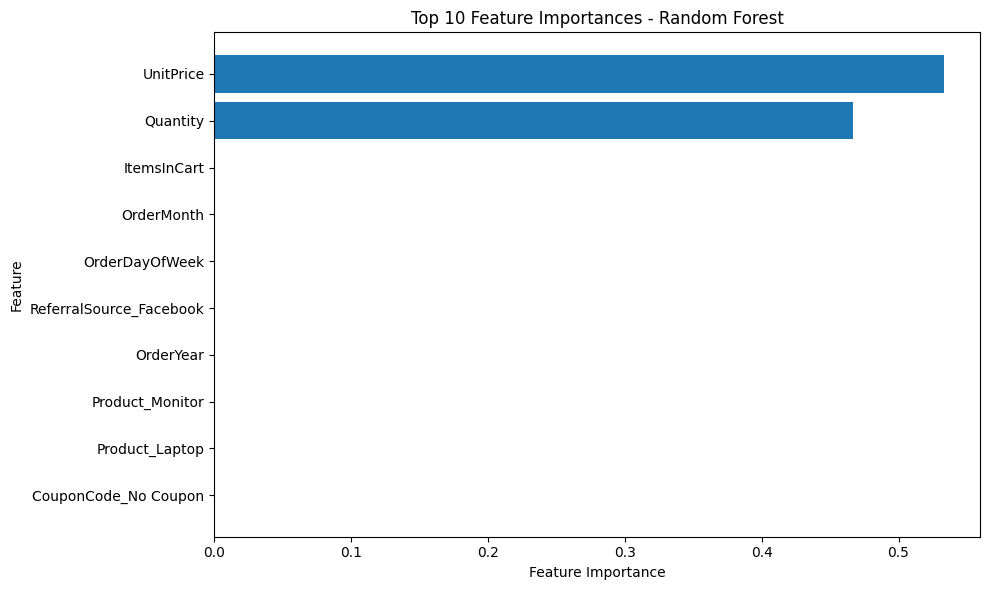

In [31]:
top_10 = feature_importance.head(10).sort_values('Importance')
plt.figure(figsize=(10, 6))
plt.barh(top_10['Feature'], top_10['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 10 Feature Importances - Random Forest')
plt.tight_layout()
plt.show()

### Interpretation

UnitPrice and Quantity were the dominant predictors of TotalPrice. Their feature importance values were 0.532861 and 0.466651 respectively, together accounting for approximately 99.95% of the total feature importance.

## 12. Findings and Recommendations

### Key Findings

- The dataset contained 1,200 order records.
- CouponCode contained 309 missing values, which were treated as "No Coupon".
- Eight TotalPrice outliers were identified and capped.
- UnitPrice and Quantity showed the strongest relationships with TotalPrice.
- Random Forest achieved the strongest predictive performance.
- UnitPrice and Quantity accounted for approximately 99.95% of Random Forest feature importance.

### Recommendations

1. Focus on pricing and quantity-based order analysis.
2. Monitor high-value orders.
3. Use predictive models for order-value estimation.
4. Continue monitoring customer and transaction variables.
5. Improve future data collection with additional customer and product information.

# 13. Conclusion

This project analyzed e-commerce order data and developed machine learning regression models for predicting TotalPrice. Among the three evaluated models, Random Forest achieved the strongest performance, with an R² of 0.9997 and an RMSE of 14.56.

Feature importance analysis showed that UnitPrice and Quantity were the dominant predictors of TotalPrice. The project demonstrates a complete data analytics and machine learning workflow, from data cleaning and exploratory analysis through model development, evaluation, and interpretation.

The exceptionally high predictive performance should be interpreted in the context of the strong mathematical relationship between TotalPrice, UnitPrice, and Quantity.